Prashun Kafle

# Deliverable 2

## 1. Problem Statement:
### *The goal is to build a model that predicts the number of border crossings (“Value”) at U.S. land ports using features such as port location, border type, crossing category (Measure), and date information (Year and Month).*

## 2. Exploratory Data Analysis (EDA):

In [2]:
#Necessary Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("Border_Crossing_Entry_Data.csv")
df.head()


,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Point
0,Jackman,Maine,104,US-Canada Border,Jan 2024,Trucks,6556,45.806,-70.397,POINT (-70.396722 45.805661)
1,Porthill,Idaho,3308,US-Canada Border,Apr 2024,Trucks,98,49.000,-116.499,POINT (-116.49925 48.999861)
2,San Luis,Arizona,2608,US-Mexico Border,Apr 2024,Buses,10,32.485,-114.782,POINT (-114.7822222 32.485)
3,Willow Creek,Montana,3325,US-Canada Border,Jan 2024,Pedestrians,2,49.000,-109.731,POINT (-109.731333 48.999972)
4,Warroad,Minnesota,3423,US-Canada Border,Jan 2024,Personal Vehicle Passengers,9266,48.999,-95.377,POINT (-95.376555 48.999)


In [4]:
df.isnull().sum()

Port Name    0
State        5
Port Code    0
Border       0
Date         0
Measure      0
Value        0
Latitude     7
Longitude    7
Point        7
dtype: int64

In [5]:
df = df.drop(columns=['Point']) #dropping 'Point' column as theres no use of it in prediction
df['State'] = df['State'].fillna('Unknown') #filling missing values in 'State' with 'Unknown'
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median()) #filling missing values in 'Latitude' with median
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median()) #filling missing values in 'Longitude' with median

#date formatting
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.drop_duplicates(inplace=True)#removing duplicates

df['Measure'] = df['Measure'].str.strip()#removing leading and trailing spaces
df['Port Name'] = df['Port Name'].str.strip()

C:\Users\DSU Student\AppData\Local\Temp\ipykernel_26924\4043610745.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


## 3. Correlation Analysis:

Correlation matrix:
              Value  Port Code  Latitude  Longitude      Year     Month
Value      1.000000  -0.010199 -0.230101  -0.037247  0.000227  0.005179
Port Code -0.010199   1.000000  0.171840  -0.738757 -0.018795 -0.001349
Latitude  -0.230101   0.171840  1.000000  -0.045284 -0.018799  0.000173
Longitude -0.037247  -0.738757 -0.045284   1.000000  0.013147  0.001279
Year       0.000227  -0.018795 -0.018799   0.013147  1.000000 -0.004561
Month      0.005179  -0.001349  0.000173   0.001279 -0.004561  1.000000


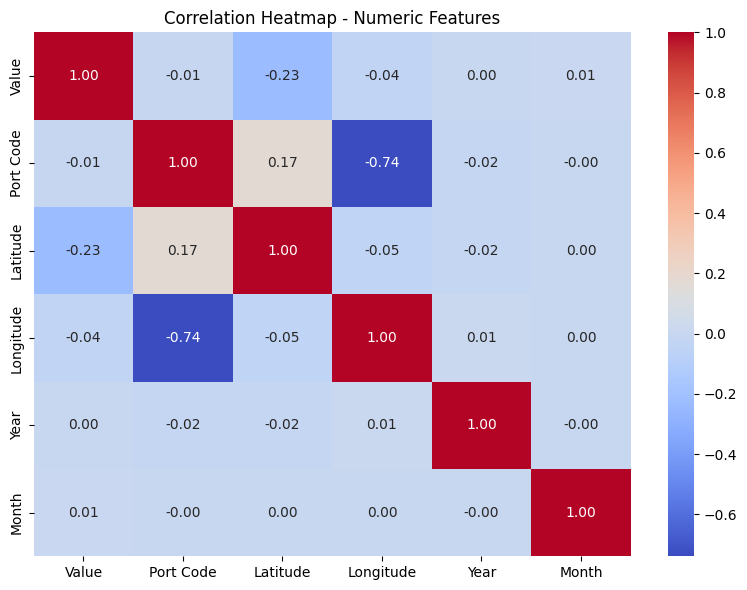

In [6]:
num_cols = ['Value', 'Port Code', 'Latitude', 'Longitude', 'Year', 'Month']
df_num = df[num_cols]

# 2. Compute correlation matrix
corr = df_num.corr()
print("Correlation matrix:")
print(corr)

# 3. Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap - Numeric Features")
plt.tight_layout()
plt.show()

## Correlation Matrix:
### In the correlation matrix above we can see that the correlation between Port Code and Longitude is -0.74 which is a strong negative correlation. The next strongest correlation is between Value(Count of recorded entries for the given measure at the given port) and Latitude which is -0.23 which is a weak negative correlation. The rest of the correlations are very weak and close to zero. 

## Multicollinearity: 
### Since the correlation (–0.74) is noticeable but not extreme, it does not cause major multicollinearity problems. However, Port Code is essentially an ID column, so it may not add meaningful predictive value. If needed, later on we can drop Port Code and keep Longitude.

# 4. Principal Component Analysis (PCA):

In [7]:
num_cols = ['Value', 'Port Code', 'Latitude', 'Longitude', 'Year', 'Month']
X = df[num_cols]

print("Max absolute correlation:", X.corr().abs().max().max())

X_scaled = StandardScaler().fit_transform(X)
pca = PCA().fit(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum())


Max absolute correlation: 1.0
Explained variance ratio: [0.29525265 0.20361572 0.16742557 0.16577876 0.12621322 0.04171408]
Cumulative explained variance: [0.29525265 0.49886838 0.66629394 0.8320727  0.95828592 1.        ]


### We do not need to use PCA because our numeric features are not highly correlated, and the PCA results show that dimensionality reduction wouldn’t help. The cumulative explained variance only reaches about 30% with the first component, 50% with the second, and doesn’t hit around 95% until the fifth out of six components. Since PCA would still require almost the entire original feature set to retain the information, it provides no real simplification for our dataset.

# 5. Data Cleaning:

### We cleaned the dataset by removing unnecessary columns, fixing missing values, standardizing formats, and preparing the features for modeling. We dropped the “Point” column because it only duplicated the latitude and longitude information. Missing states were filled with “Unknown,” and missing latitude/longitude values were replaced with the median to avoid losing rows. We converted the Date column to a proper datetime format and extracted the Year and Month to make the time information usable for modeling. We also removed duplicate rows and trimmed extra spaces from text fields like Port Name and Measure to prevent inconsistent categories. After these steps, the dataset had no missing values and was fully prepared for the modeling stage.

# 6. Predictive Modeling Approaches:

### For this project, we will be using 3 different predictive modeling approaches to predict the number of border crossings(Value). Each model has a different complexity level. Starting with the first and least complex and so on:
### - Linear Regression: This model will help us to create a baseline for out predicitions. Its is easy to interpret and can show us the linear relationship between the features and the target variable. 
### - Random Forest Regressor: Random Forest is an ensemble learning method that helps to capture non-linear relationships and interactions between features. This allows us to take our prediction to the next level and improve out accuracy.
### - Histogram Gradient Boosting Regressor: This model is a powerful boosting algorithm that works by building an ensemble of decision trees sequentially, where each tree corrects the errors of the previous ones. This model is specially effective for handling complex datasets that may have non-linear relationships and interactions between features. This model can help us to further improve our predictions and achieve better performance compared to the previous two models.  